In [115]:
using Pkg
Pkg.develop(path="../apuu")

using Revise
using apuu.RobotEnv2D: POMDPscenario, GenerateRangedObservationFromBeacons, GenerateSingleRangedBeaconObservation, beacon_grid, GenerateObservationFromBeacons, SampleMotionModel
using apuu.GaussianFilter: PropagateBelief, PosteriorBeliefRangedBeacons, PosteriorBeliefBeacons
using apuu.Paths: HW3_PLOTS

using Revise
using Distributions
using Random
using LinearAlgebra
using Plots
using StatsPlots
using Parameters
using StatsBase

   Resolving package versions...
     Project No packages added to or removed from `C:\Users\amir.livny\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\amir.livny\.julia\environments\v1.12\Manifest.toml`


In [116]:
# definition of the random number generator with seed
ID = 318803129
rng = MersenneTwister(ID)

# parameters
μ0 = [0.0, 0.0]
Σ0 = 0.1 * I(2)
F = I(2)
Σw = 0.1^2 * I(2)
Σv = 0.1^2 * I(2) # place holder for the non-ranged setting, measurement noise is dynamically changing in this setting
d = 1.0
rmin = 0.1
beacons = beacon_grid()

𝒫 = POMDPscenario(F=F, Σw=Σw, Σv=Σv, rng=rng, beacons=beacons, d=d, rmin=rmin)

POMDPscenario
  F: Array{Float64}((2, 2)) [1.0 0.0; 0.0 1.0]
  Σw: Array{Float64}((2, 2)) [0.010000000000000002 0.0; 0.0 0.010000000000000002]
  Σv: Array{Float64}((2, 2)) [0.010000000000000002 0.0; 0.0 0.010000000000000002]
  rng: MersenneTwister
  beacons: Array{Float64}((9, 2)) [0.0 0.0; 4.5 0.0; … ; 4.5 9.0; 9.0 9.0]
  d: Float64 1.0
  rmin: Float64 0.1


## 1 -  TransitBeliefMDP

In [117]:
"""
Transform the given POMDP scenario into a Belief-MDP based on transition and observation models. First propagate the belief throught the motion model, then sample a state from the propagated belief, then sample an observation from that state, and finally update the belief based on the action and observation.
"""
function TransitBeliefMDP(𝒫::POMDPscenario, b::MvNormal, a::Vector{Float64})::MvNormal
    # propagate the belief through the motion model
    b_pred = PropagateBelief(𝒫, b, a)

    # sample a state from the propagated belief
    x_prime = rand(𝒫.rng, b_pred)

    # sample an observation from x'
    z_tuple = GenerateRangedObservationFromBeacons(𝒫, x_prime)

    # update the belief based on the action and observation
    if isnothing(z_tuple)
        return b_pred
    else
        return PosteriorBeliefRangedBeacons(𝒫, b, a, z_tuple)
    end
end

TransitBeliefMDP

In [118]:
x0 = [-0.5, -0.2] # ground truth initial state
b0 = MvNormal(μ0, Σ0) # initial belief
function cost_function(b::MvNormal, x_goal::Vector{Float64}, λ::Float64)::Float64
    return norm(b.μ - x_goal, 2) + λ * det(b.Σ)
end

# action space is all directions, plus diagonals, plus zero action
action_space = [ [0.0, 0.0],
                 [1.0, 0.0], [-1.0, 0.0],
                 [0.0, 1.0], [0.0, -1.0],
                 [1.0, 1.0]/sqrt(2), [1.0, -1.0]/sqrt(2),
                 [-1.0, 1.0]/sqrt(2), [-1.0, -1.0]/sqrt(2) ]
num_actions = length(action_space)

9

## 2

### (a) Sparse Sampling Implementation

In [119]:
function SelectActionSparseSampling(
    𝒫::POMDPscenario, 
    b::MvNormal,
    x_goal::Vector{Float64}, 
    λ::Float64, 
    d::Int, 
    n::Int
    )::Tuple{Vector{Float64}, Float64}

    if d == 0
        return ([0.0, 0.0], 0.0) 
    end

    best_a = [0.0, 0.0]
    best_v = Inf 

    for a in action_space
        q = 0.0
        r = cost_function(b, x_goal, λ) 

        for i in 1:n
            b_prime = TransitBeliefMDP(𝒫, b, a)
            (_, v_prime) = SelectActionSparseSampling(𝒫, b_prime, x_goal, λ, d - 1, n)
            q = q + (r + v_prime) / n
        end

        if q < best_v
            best_v = q
            best_a = a
        end
    end

    return (best_a, best_v)
end

SelectActionSparseSampling (generic function with 1 method)

### (b) Compare different parameters
We tried multiple choices for $\lambda$ and $n$.
One choice is $\lambda=500$ which interestingly visits a second beacon. These parameters also achieve a trajectory that ends very close to the goal, as the uncertainty is low after the second beacon visit. For small values of lambda we noticed that the trajectory only gets an observation from the (0, 0) beacon and thus the belief is less accurate later on.

In [120]:
# chosen parameters
x_goal = [6.0, -3.0]
d = 4
λ = 500.0
n = 3

3

### (c) Consequetive planning sessions

In [121]:
# Initializations
x_gt = x0
b = b0
trajectory = Vector{Float64}[x_gt]
observations = Union{NamedTuple, Nothing}[]
beliefs = AbstractMvNormal[b]

for t in 1:10
    # 1. Plan: Find best action using Sparse Sampling
    (a_opt, v_opt) = SelectActionSparseSampling(𝒫, b, x_goal, λ, d, n)
    
    # 2. Act: Move the REAL robot (Ground Truth)
    x_gt = SampleMotionModel(𝒫, a_opt, x_gt)
    push!(trajectory, x_gt)
    
    # 3. Observe: Generate a REAL observation from the new GT state
    z_tuple = GenerateRangedObservationFromBeacons(𝒫, x_gt)
    push!(observations, z_tuple)
    
    # 4. Update: Update belief with the action and REAL observation
    if isnothing(z_tuple)
        b = PropagateBelief(𝒫, b, a_opt)
    else
        b = PosteriorBeliefRangedBeacons(𝒫, b, a_opt, z_tuple)
    end
    push!(beliefs, b)
end

### (d), (e), (f) Plotting

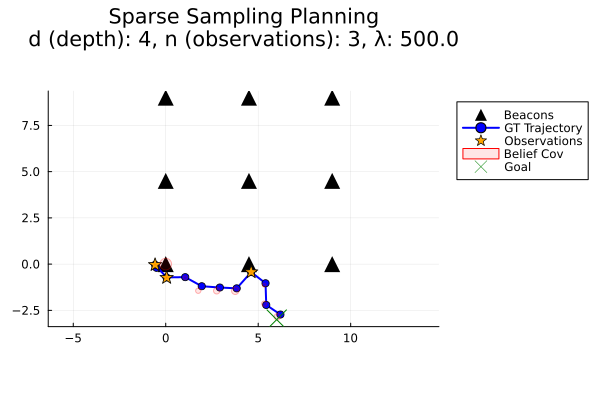

In [122]:
# 1. Setup the base plot with beacons 
p = scatter(beacons[:, 1], beacons[:, 2], 
            label="Beacons", markershape=:utriangle, markersize=8, 
            c=:black, aspect_ratio=:equal, legend=:outertopright)

# 2. Plot the Ground Truth Trajectory 
plot!(p, [pos[1] for pos in trajectory], [pos[2] for pos in trajectory], 
      label="GT Trajectory", lw=2, c=:blue, marker=:circle)

# 3. Plot Observations 
# We only plot if z_tuple was not nothing. Observations are relative to beacons.
obs_x = []
obs_y = []
for (i, z) in enumerate(observations)
    if !isnothing(z)
        # Reconstruct absolute position: beacon_pos + relative_obs
        abs_z = 𝒫.beacons[z.beacon_index, :] + z.obs
        push!(obs_x, abs_z[1])
        push!(obs_y, abs_z[2])
    end
end
scatter!(p, obs_x, obs_y, label="Observations", markershape=:star5, c=:orange, markersize=7)

# 4. Plot Beliefs (Mean and Covariance Ellipses) 
for (i, bel) in enumerate(beliefs)
    # Draw the 1-sigma covariance ellipse
    covellipse!(p, bel.μ, bel.Σ, n_std=1, label=(i==1 ? "Belief Cov" : ""), 
                lc=:red, lw=1, fillalpha=0.1, fc=:red)
end

# 5. Mark the Goal
scatter!(p, [x_goal[1]], [x_goal[2]], label="Goal", markershape=:xcross, markersize=10, c=:green)

param_info = "d (depth): $d, n (observations): $n, λ: $λ"
title!(p, "Sparse Sampling Planning\n$param_info")
display(p)

In [123]:
# Final ground truth distance to goal
norm(trajectory[end] - x_goal, 2)

0.3395874510857833